# ClinVar Genetic Variant Classification


**Խնդիրը (Problem):** կանխատեսել՝ արդյոք տվյալ գենետիկ վարիանտը կունենա


հակասական կլինիկական դասակարգում (conflicting classification), թե ոչ։

**Տվյալները (Data):** ClinVar (NCBI) — մարդու գենետիկ վարիանտների հանրային բազա։

Kaggle dataset → `kevinarvai/clinvar-conflicting`

**Խնդրի տիպը (Problem type):** Binary Classification
- `CLASS = 0` → consistent classifications (համահունչ)
- `CLASS = 1` → conflicting classifications (հակասական)

**Workflow.** ամբողջ pipeline-ը՝ EDA → preprocessing → one-hot encoding → feature engineering → 11 մոդելի համեմատություն → final report։

In [81]:
!pip install -q kagglehub xgboost lightgbm

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

## 1.Data Upload

In [83]:
df = pd.read_csv("clinvar_conflicting.csv")
print(df.shape)

(65188, 46)


/tmp/ipykernel_5836/2615251279.py:1: DtypeWarning: Columns (0,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clinvar_conflicting.csv")


## 2.Data Exploration (EDA) — տվյալները ուսումնասիրենք

Tutor-ի պահանջած քայլերը.
- քանի row և column
- ամեն սյունակի type-ը
- վիճակագրական ամփոփ (mean, max, percentiles)
- correlation
- missing values
- visualization

In [84]:
# Հասկանանք data-ն ինչ տեսք ունի
df.head()

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.1168180G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q96L58#VAR_059317,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,protein_coding,1/1,NaN,552,522,174,E/D,gaG/gaC,NaN,1.0,NaN,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,NaN,NC_000001.10:g.1470752G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:616101.0001|UniProtKB_(pr...,SO:0001583|missense_variant,1,NaN,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,protein_coding,4/4,NaN,523,509,170,P/L,cCg/cTg,NaN,-1.0,OK,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NaN,NC_000001.10:g.1737942A>G,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:139380.0002|UniProtKB_(pr...,"SO:0001583|missense_variant,SO:0001623|5_prime...",35,NaN,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,protein_coding,6/12,NaN,632,239,80,I/T,aTc/aCc,NaN,-1.0,OK,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160305G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0004|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/S,Ggc/Agc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,NaN,NC_000001.10:g.2160305G>T,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0005|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/C,Ggc/Tgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0


In [85]:
# Չափը՝
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 65188
Columns: 46


In [86]:
# Ամեն column-ի type-ը + քանի non-null արժեք ունի
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHROM               65188 non-null  object 
 1   POS                 65188 non-null  int64  
 2   REF                 65188 non-null  object 
 3   ALT                 65188 non-null  object 
 4   AF_ESP              65188 non-null  float64
 5   AF_EXAC             65188 non-null  float64
 6   AF_TGP              65188 non-null  float64
 7   CLNDISDB            65188 non-null  object 
 8   CLNDISDBINCL        167 non-null    object 
 9   CLNDN               65188 non-null  object 
 10  CLNDNINCL           167 non-null    object 
 11  CLNHGVS             65188 non-null  object 
 12  CLNSIGINCL          167 non-null    object 
 13  CLNVC               65188 non-null  object 
 14  CLNVI               27659 non-null  object 
 15  MC                  64342 non-null  object 
 16  ORIG

In [87]:
# Վիճակագրական թվային սյունակների համար (mean,std,min,max,percentiles)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
POS,65188.0,7.757594e+07,5.974051e+07,961.000000,3.254179e+07,5.797021e+07,1.127454e+08,2.476080e+08
AF_ESP,65188.0,1.451052e-02,5.779541e-02,0.000000,0.000000e+00,0.000000e+00,1.200000e-03,4.990000e-01
AF_EXAC,65188.0,1.449218e-02,5.954210e-02,0.000000,0.000000e+00,4.000000e-05,1.230000e-03,4.998900e-01
AF_TGP,65188.0,1.526350e-02,5.952741e-02,0.000000,0.000000e+00,0.000000e+00,1.600000e-03,4.998000e-01
ORIGIN,65188.0,1.342486e+00,5.688772e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,5.130000e+02
SSR,130.0,2.269231e+00,4.190777e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.600000e+01
CLASS,65188.0,2.521016e-01,4.342226e-01,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
DISTANCE,108.0,8.257315e+02,1.069363e+03,1.000000,5.550000e+01,4.690000e+02,1.415000e+03,4.759000e+03
STRAND,65174.0,-6.659097e-03,9.999855e-01,-1.000000,-1.000000e+00,-1.000000e+00,1.000000e+00,1.000000e+00
MOTIF_POS,2.0,1.000000e+00,0.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


###Target-ի բաշխվածությունը (Class imbalance)

`CLASS`-ը մեր target-ն է։ Ստուգենք՝ արդյոք երկու class-ները հավասար են։


CLASS
0    48754
1    16434
Name: count, dtype: int64

Տոկոսներով:
CLASS
0    74.8
1    25.2
Name: proportion, dtype: float64


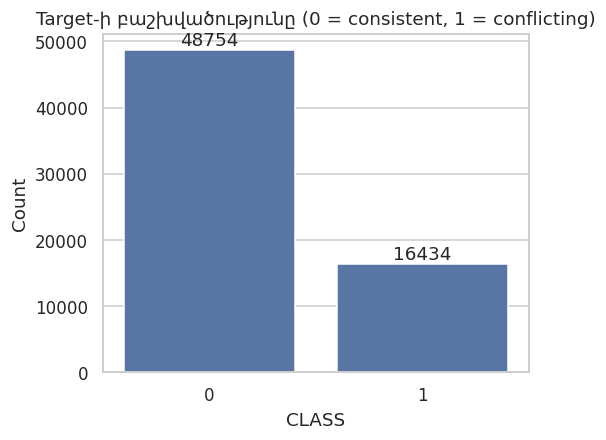

In [88]:
# Քանի՞ 0 և քանի՞ 1 ունենք

print(df["CLASS"].value_counts())
print("\nՏոկոսներով:")
print((df["CLASS"].value_counts(normalize=True) * 100).round(1))

plt.figure(figsize=(5, 4))
ax = sns.countplot(x="CLASS", data=df)
ax.set_title("Target-ի բաշխվածությունը (0 = consistent, 1 = conflicting)")
ax.set_xlabel("CLASS")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Նկատում.** Class-ները հավասար չեն (≈75% vs 25%) → ունենք **class imbalance**։
Դրա համար մոդելներում կօգտագործենք `class_weight="balanced"` (և XGBoost-ի համար՝ `scale_pos_weight`),
իսկ գնահատելիս կնայենք ոչ թե միայն Accuracy-ին, այլ **F1, Precision, Recall, ROC-AUC**-ին։

                    missing_count  missing_%
HIGH_INF_POS                65186      100.0
MOTIF_SCORE_CHANGE          65186      100.0
MOTIF_NAME                  65186      100.0
MOTIF_POS                   65186      100.0
DISTANCE                    65080       99.8
SSR                         65058       99.8
CLNDNINCL                   65021       99.7
CLNSIGINCL                  65021       99.7
CLNDISDBINCL                65021       99.7
INTRON                      56385       86.5
PolyPhen                    40392       62.0
SIFT                        40352       61.9
BLOSUM62                    39595       60.7
CLNVI                       37529       57.6
BAM_EDIT                    33219       51.0
Amino_acids                 10004       15.3
Codons                      10004       15.3
Protein_position             9955       15.3
CDS_position                 9955       15.3
EXON                         8893       13.6
cDNA_position                8884       13.6
LoFtool   

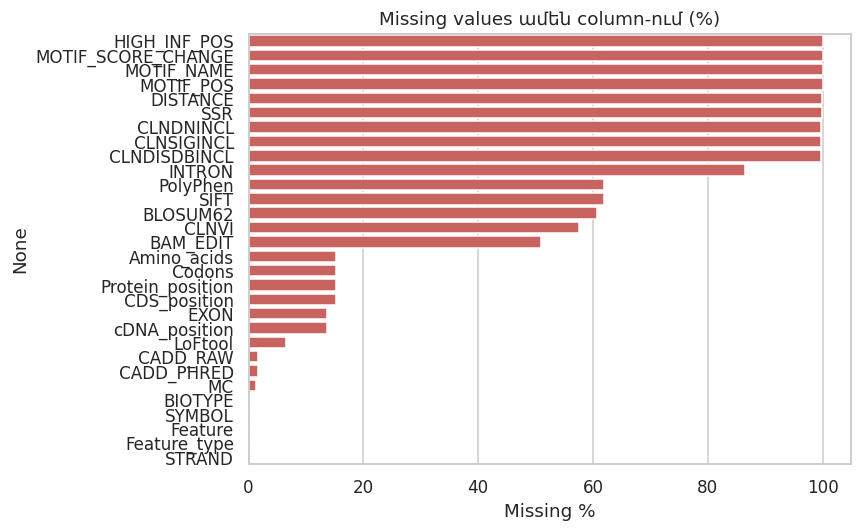

In [89]:
# Missing value-ները ստուգենք ամեն column-ի համար

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print(missing_table)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#d9534f")
plt.title("Missing values ամեն column-ում (%)")
plt.xlabel("Missing %")
plt.tight_layout()
plt.show()

**Նկատում.** Մի քանի column գրեթե դատարկ են (շատ NaN)։ Դրանք preprocessing-ի ժամանակ կջնջենք։

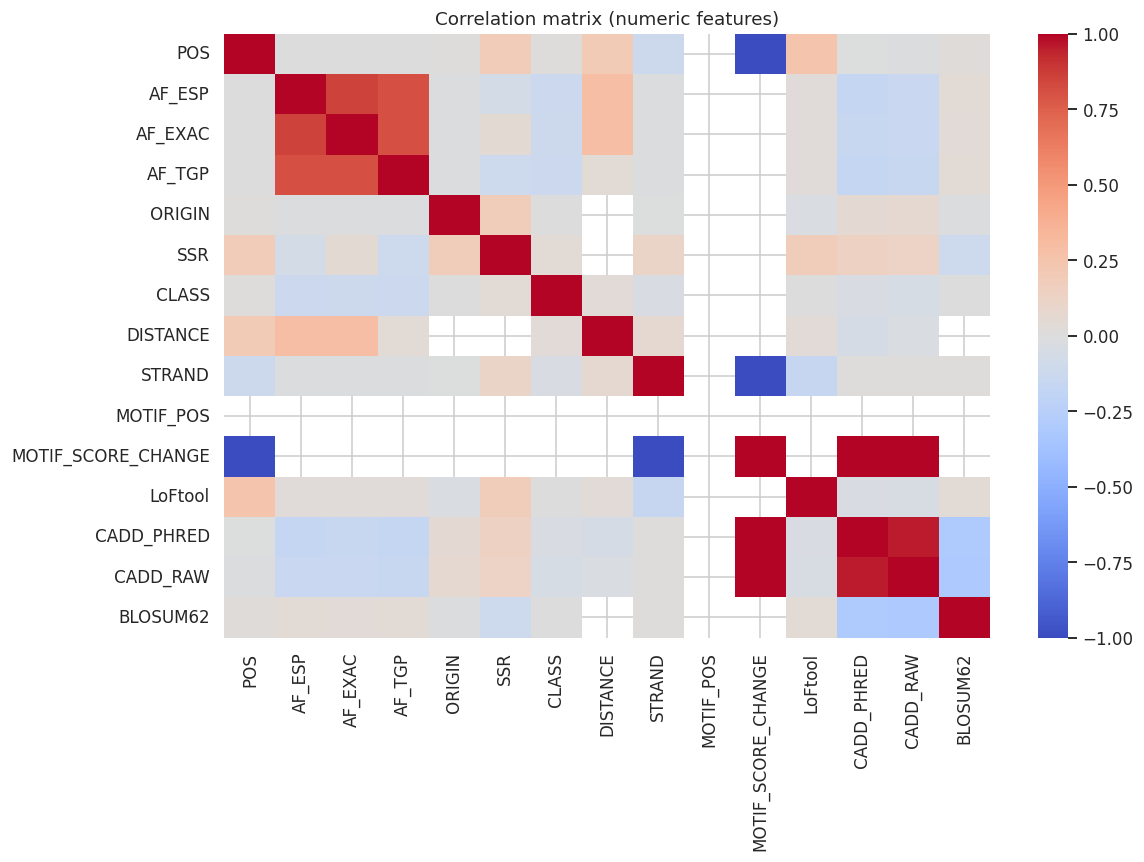

In [90]:
# Correlation heatmap թվային սյունակների միջև
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(11, 8))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

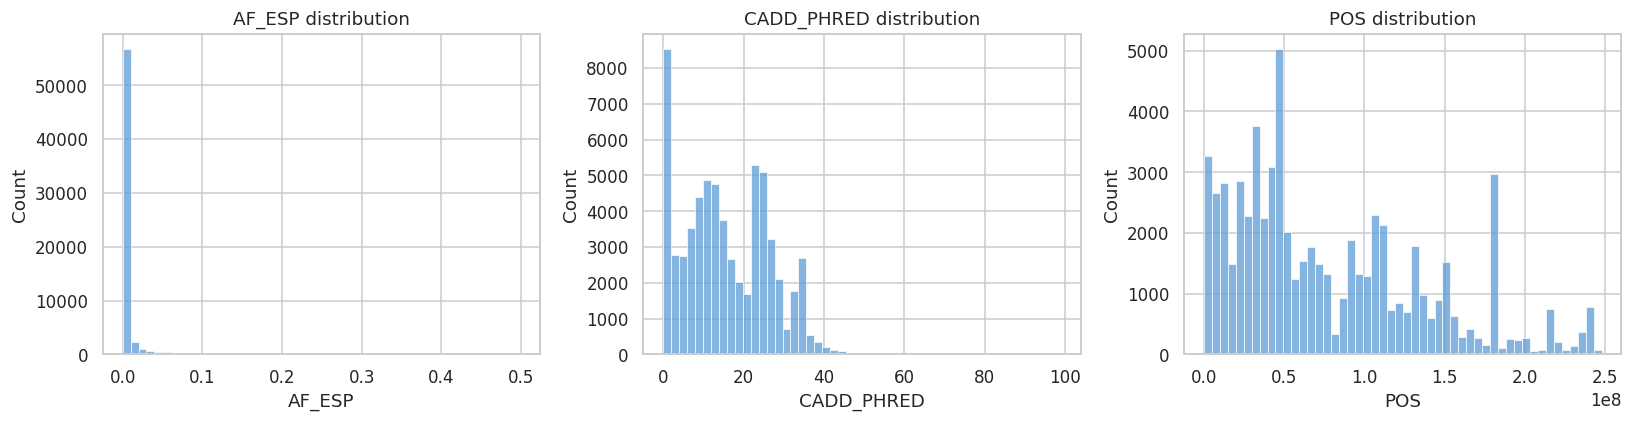

In [91]:
# Մի քանի կարևոր թվային feature-ի distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["AF_ESP", "CADD_PHRED", "POS"]):
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=50, ax=ax, kde=False, color="#5b9bd5")
        ax.set_title(f"{col} distribution")
plt.tight_layout()
plt.show()

In [92]:
print(df.IMPACT)

0        MODERATE
1        MODERATE
2        MODERATE
3        MODERATE
4        MODERATE
           ...   
65183         LOW
65184    MODERATE
65185         LOW
65186         LOW
65187    MODERATE
Name: IMPACT, Length: 65188, dtype: object


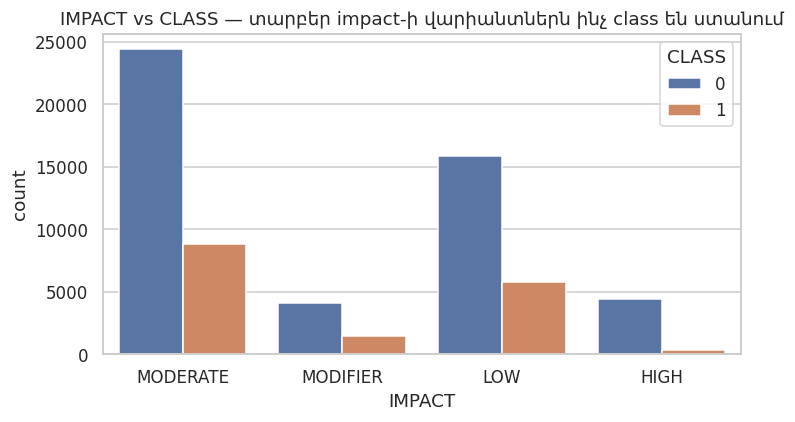

In [93]:
# Կատեգորիկ feature vs target — օրինակ՝ վարիանտի IMPACT-ը ինչպես է կապված class-ի հետ

if "IMPACT" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(x="IMPACT", hue="CLASS", data=df)
    plt.title("IMPACT vs CLASS — տարբեր impact-ի վարիանտներն ինչ class են ստանում")
    plt.tight_layout()
    plt.show()

## 3.Data Preparation

Քայլերը.
1. Ջնջենք **leakage / ID-type** column-ները (որոնք պատասխանը «մատնում» են կամ ուղղակի ունիկալ ID են)
2. Ջնջենք column-ները, որոնք **>50% missing** են
3. Թվային column-ները բերենք իրական numeric type-ի (errors → NaN)

In [94]:
# Սրանք ID-type / leakage column-ներ են. Չեն օգնում մոդելին, պետք է ջնջել.
# - CLNHGVS, CLNVI: գրեթե ունիկալ ID-ներ
# - CLNDISDB: հիվանդության DB cross-reference (free text, շատ բարդ)

leakage_cols = ["CLNHGVS", "CLNVI", "CLNDISDB"]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
print("Ջնջեցինք leakage columns:", [c for c in leakage_cols if c not in df.columns])

# Թվային column-ները՝ որ to_numeric անենք (եթե ինչ-որ տեղ տեքստ լինի,դառնում է NaN)

numeric_like = ["POS", "AF_ESP", "AF_EXAC", "AF_TGP", "cDNA_position",
                "CDS_position", "Protein_position", "DISTANCE", "STRAND",
                "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62",
                "MOTIF_POS", "MOTIF_SCORE_CHANGE", "ORIGIN", "SSR"]
for c in numeric_like:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Ջնջենք column-ները, որ >50% missing են (շատ դատարկ են,օգուտ չունեն)

missing_frac = df.isna().mean()
too_empty = missing_frac[missing_frac > 0.5].index.tolist()
too_empty = [c for c in too_empty if c != "CLASS"]
df = df.drop(columns=too_empty)
print("Ջնջեցինք >50% դատարկ columns:", too_empty)
print("Մնացած shape:", df.shape)

Ջնջեցինք leakage columns: ['CLNHGVS', 'CLNVI', 'CLNDISDB']
Ջնջեցինք >50% դատարկ columns: ['CLNDISDBINCL', 'CLNDNINCL', 'CLNSIGINCL', 'SSR', 'INTRON', 'DISTANCE', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'BLOSUM62']
Մնացած shape: (65188, 29)


### One-Hot Encoding vs Frequency Encoding

Մոդելները տեքստ չեն հասկանում,ուստի կատեգորիկ սյունակները պետք է թվայնացնենք։
Բայց ոչ բոլորը նույն ձևով.

- **One-Hot Encoding** → օգտագործում ենք քիչ տարբեր արժեք ունեցող սյունակների համար
  (օր. `IMPACT`, `CHROM`)։ Ամեն կատեգորիա դառնում է առանձին 0/1 column։
- **Frequency Encoding** → օգտագործում ենք շատ տարբեր արժեք ունեցողների համար
  (օր. `SYMBOL` = գենի անունը, որ հազարավոր տարբեր արժեք ունի)։ Եթե սրանց one-hot անենք,
  կստեղծվի հազարավոր column ու մոդելը կփչանա։
  Փոխարենը՝ ամեն կատեգորիա փոխարինում ենք իր հանդիպման հաճախականությամբ։

Ստորև ամբողջ preprocessing-ը գրում ենք **մեկ function-ի մեջ**, որ հետո հեշտ կանչենք
և՛ feature engineering-ով, և՛ առանց դրա (որ համեմատենք)։

In [95]:
def build_features(df_raw, add_engineered=True, hi_card_threshold=25):

    """
    Ամբողջ preprocessing-ը մեկ տեղում.
    add_engineered=True  -> ավելացնում ենք նոր feature-ներ (feature engineering)
    add_engineered=False -> միայն base feature-ները (baseline)
    """
    df = df_raw.copy()

    # target-ը առանձնացնենք
    y = df["CLASS"].astype(int)
    df = df.drop(columns=["CLASS"])

    # annotation-ի դատարկության չափը պահենք (feature engineering-ի համար)
    n_missing_full = df.isna().sum(axis=1)

    # Allele frequency-ի NaN-երը 0 ենք դնում
    # (genomics-ում NaN AF սովորաբար նշանակում է՝ վարիանտը չի դիտվել -> շատ հազվադեպ -> ~0)

    for c in ["AF_ESP", "AF_EXAC", "AF_TGP"]:
        if c in df.columns:
            df[c] = df[c].fillna(0)


    # FEATURE ENGINEERING — նոր feature-ներ

    if add_engineered:
        ref_len = df["REF"].astype(str).str.len()
        alt_len = df["ALT"].astype(str).str.len()
        df["ref_len"] = ref_len
        df["alt_len"] = alt_len
        df["is_snv"] = ((ref_len == 1) & (alt_len == 1)).astype(int)   # single nucleotide variant?
        df["indel_size"] = (ref_len - alt_len).abs()                   # ինսերշն/դելեցիայի չափ

        af_cols = [c for c in ["AF_ESP", "AF_EXAC", "AF_TGP"] if c in df.columns]
        if af_cols:
            df["af_max"] = df[af_cols].max(axis=1)
            df["af_mean"] = df[af_cols].mean(axis=1)
            df["is_rare"] = (df["af_max"] < 0.01).astype(int)          # հազվադեպ վարիանտ?

        if "CADD_PHRED" in df.columns:
            df["cadd_high"] = (df["CADD_PHRED"] > 20).astype(int)      # հայտնի pathogenicity threshold

        df["n_missing_annotations"] = n_missing_full                   # քանի annotation է բացակայում



    # Numeric vs Categorical բաժանում

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # numeric NaN-երը լրացնենք median-ով
    for c in num_cols:
        df[c] = df[c].fillna(df[c].median())

    # categorical NaN-երը լրացնենք "Unknown"-ով
    for c in cat_cols:
        df[c] = df[c].fillna("Unknown").astype(str)

    # categorical-ները բաժանենք ըստ cardinality-ի
    low_card  = [c for c in cat_cols if df[c].nunique() <= hi_card_threshold]
    high_card = [c for c in cat_cols if df[c].nunique() >  hi_card_threshold]

    # high-cardinality -> FREQUENCY ENCODING
    for c in high_card:
        freq = df[c].value_counts(normalize=True)
        df[c + "_freq"] = df[c].map(freq)
    df = df.drop(columns=high_card)

    # low-cardinality -> ONE-HOT ENCODING
    df = pd.get_dummies(df, columns=low_card, drop_first=True)

    # ամեն ինչ թվային դարձնենք (get_dummies-ի bool-երը -> int)
    X = df.astype(float)
    return X, y, {"one_hot": low_card, "freq_encoded": high_card}


# Փորձարկենք function-ը engineered version-ով
X_eng, y, enc_info = build_features(df, add_engineered=True)
print("Engineered feature set shape:", X_eng.shape)
print("\nOne-hot արված columns:", enc_info["one_hot"])
print("\nFrequency-encoded columns:", enc_info["freq_encoded"])

Engineered feature set shape: (65188, 68)

One-hot արված columns: ['CHROM', 'CLNVC', 'IMPACT', 'Feature_type', 'BIOTYPE']

Frequency-encoded columns: ['REF', 'ALT', 'CLNDN', 'MC', 'Allele', 'Consequence', 'SYMBOL', 'Feature', 'EXON', 'Amino_acids', 'Codons']


## Outliers + Normalization

Ստուգենք ծայրահեղ արժեքները (outliers) մի քանի թվային feature-ի վրա boxplot-ով։
Tree-based մոդելները (Random Forest, XGBoost) outlier-ներից չեն տուժում, բայց
LogReg/KNN/SVM-ի համար կարևոր է normalization-ը — դա կանենք train/test բաժանելուց հետո
(որ test-ի info-ն "չարտահոսի" train մեջ)։

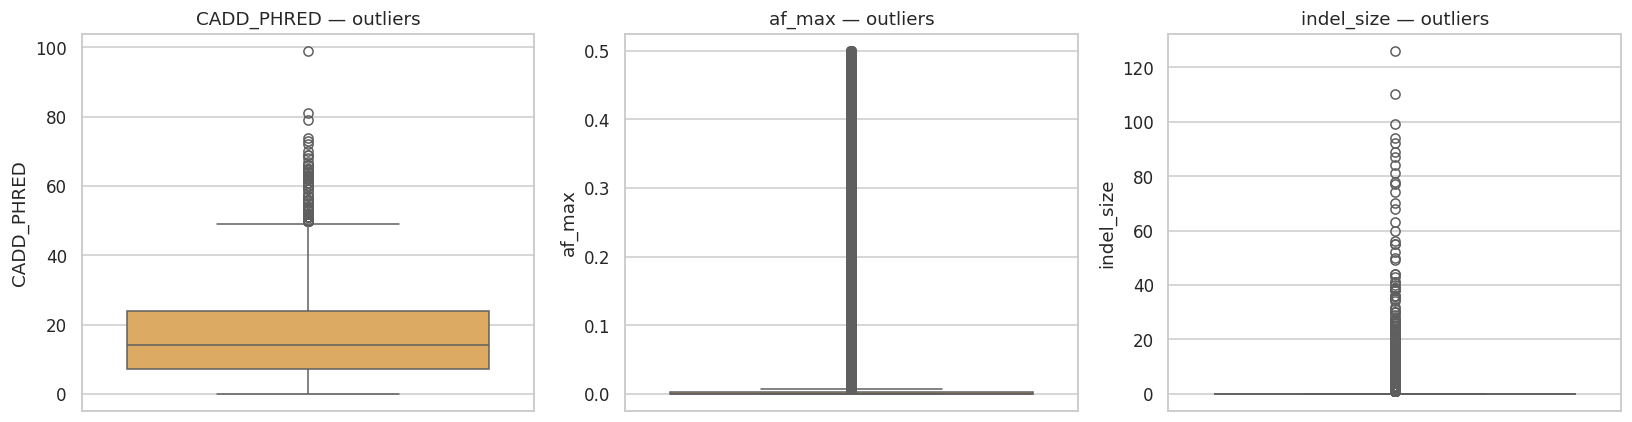

In [96]:
# Boxplot-ներ outlier տեսնելու համար

check_cols = [c for c in ["CADD_PHRED", "af_max", "indel_size"] if c in X_eng.columns]
fig, axes = plt.subplots(1, len(check_cols), figsize=(5*len(check_cols), 4))
if len(check_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, check_cols):
    sns.boxplot(y=X_eng[col], ax=ax, color="#f0ad4e")
    ax.set_title(f"{col} — outliers")
plt.tight_layout()
plt.show()

## Feature Engineering — ինչ նոր feature-ներ ստեղծեցինք

Ստեղծեցինք domain-ի վրա հիմնված նոր feature-ներ.

| Feature | Ինչ է նշանակում |
|---|---|
| `ref_len`, `alt_len` | reference / alternate allele-ի երկարությունը |
| `is_snv` | արդյոք single nucleotide variant է (ամենահաճախ տիպը) |
| `indel_size` | insertion/deletion-ի չափը |
| `af_max`, `af_mean` | allele frequency-ի ագրեգատներ 3 database-ից |
| `is_rare` | հազվադեպ վարիանտ է (AF < 1%) |
| `cadd_high` | CADD > 20 (pathogenicity-ի հայտնի շեմ) |
| `n_missing_annotations` | քանի annotation է բացակայում տվյալ վարիանտի համար |

Հետո կհամեմատենք՝ այս feature-ները ինչքանով են բարելավում մոդելի արդյունքը։

In [97]:
# Նայենք նոր feature-ների առաջին արժեքները
new_feats = [c for c in ["ref_len","alt_len","is_snv","indel_size",
                         "af_max","af_mean","is_rare","cadd_high",
                         "n_missing_annotations"] if c in X_eng.columns]
X_eng[new_feats].head()

,ref_len,alt_len,is_snv,indel_size,af_max,af_mean,is_rare,cadd_high,n_missing_annotations
0,1.0,1.0,1.0,0.0,0.10660,0.094633,0.0,0.0,1.0
1,1.0,1.0,1.0,0.0,0.00000,0.000000,1.0,1.0,1.0
2,1.0,1.0,1.0,0.0,0.00001,0.000003,1.0,1.0,1.0
3,1.0,1.0,1.0,0.0,0.00000,0.000000,1.0,1.0,1.0
4,1.0,1.0,1.0,0.0,0.00000,0.000000,1.0,1.0,1.0


## Train / Test Split + Scaling

Բաժանում ենք 80% train / 20% test, **stratified** (որ class-ների հարաբերակցությունը
երկու մասում էլ նույնը մնա — կարևոր է imbalance-ի դեպքում)։
StandardScaler-ը **fit ենք անում միայն train-ի վրա**։

In [98]:
def split_and_scale(X, y, test_size=0.2, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    feat_names = X.columns.tolist()
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)   # fit միայն train-ի վրա
    X_test_s = scaler.transform(X_test)         # test-ը՝ նույն scaler-ով
    return X_train_s, X_test_s, y_train.values, y_test.values, feat_names

print("Split function ready")

Split function ready


## Models

11 տարբեր մոդել ենք համեմատելու, որ տեսնենք որն է լավագույնը այս խնդրի համար։
Որտեղ հնարավոր է՝ դնում ենք `class_weight="balanced"` (imbalance-ի դեմ)։

In [99]:
# imbalance-ի համար hարաբերակցությունը (XGBoost-ի scale_pos_weight-ի համար)
spw = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight ≈ {spw:.2f}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN":                  KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes":          GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Linear SVM":           LinearSVC(class_weight="balanced", max_iter=5000),
    "Random Forest":        RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                   random_state=42, n_jobs=-1),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                                 random_state=42, n_jobs=-1),
    "AdaBoost":             AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
    "XGBoost":              XGBClassifier(n_estimators=300, eval_metric="logloss",
                                         scale_pos_weight=spw, random_state=42),
    "LightGBM":             LGBMClassifier(n_estimators=300, class_weight="balanced",
                                          random_state=42, verbose=-1),
}
print(f"Ընդամենը {len(models)} մոդել")

scale_pos_weight ≈ 2.97
Ընդամենը 11 մոդել


In [100]:
def get_scores(model, X_test):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    d = model.decision_function(X_test)
    return (d - d.min()) / (d.max() - d.min() + 1e-9)


def evaluate_models(models, X_train, X_test, y_train, y_test):
    #Ամեն մոդել train անում, գնահատում ենք, արդյունքները հավաքում աղյուսակում.

    rows, fitted, proba = [], {}, {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        score = get_scores(model, X_test)
        rows.append({
            "Model":     name,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall":    recall_score(y_test, pred, zero_division=0),
            "F1":        f1_score(y_test, pred, zero_division=0),
            "ROC_AUC":   roc_auc_score(y_test, score),
            "PR_AUC":    average_precision_score(y_test, score),
        })
        fitted[name] = model
        proba[name] = score
        print(f"  ✓ {name}")
    res = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
    return res, fitted, proba

print("Evaluation functions ready")

Evaluation functions ready


## Baseline — առանց feature engineering

Նախ train անենք բոլոր մոդելները միայն base feature-ներով (նոր feature-ներ չավելացրած),
որ հետո ունենանք համեմատելու կետ։

In [101]:
# base feature set (add_engineered=False)
X_base, y_base, _ = build_features(df, add_engineered=False)
Xtr, Xte, ytr, yte, _ = split_and_scale(X_base, y_base)

print("Baseline training սկսվեց...")
results_base, _, _ = evaluate_models(models, Xtr, Xte, ytr, yte)
print("\n BASELINE արդյունքներ:")
results_base

Baseline training սկսվեց...
  ✓ Logistic Regression
  ✓ KNN
  ✓ Naive Bayes
  ✓ Decision Tree
  ✓ Linear SVM
  ✓ Random Forest
  ✓ Extra Trees
  ✓ AdaBoost
  ✓ Gradient Boosting
  ✓ XGBoost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ✓ LightGBM

 BASELINE արդյունքներ:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.735772,0.484660,0.759355,0.591680,0.824525,0.593874
1,XGBoost,0.758168,0.515877,0.662306,0.579992,0.813057,0.574517
2,Logistic Regression,0.554840,0.335124,0.778217,0.468498,0.679026,0.377147
3,Linear SVM,0.547630,0.331570,0.781868,0.465664,0.675335,0.374071
4,Decision Tree,0.723501,0.450774,0.442957,0.446831,0.630514,0.340109
5,Random Forest,0.782175,0.651116,0.292972,0.404112,0.819903,0.579874
6,Extra Trees,0.762924,0.568340,0.247946,0.345266,0.775242,0.498329
7,Gradient Boosting,0.769520,0.625000,0.214481,0.319366,0.785813,0.527304
8,Naive Bayes,0.695352,0.343821,0.229389,0.275182,0.632832,0.327941
9,KNN,0.736386,0.441315,0.171585,0.247097,0.680184,0.377983


## With Feature Engineering — նոր feature-ներով

Հիմա նույն մոդելները train անենք նոր feature-ներով ու պահենք fitted մոդելները
(որ հետո ROC/PR/confusion matrix-ը ստանանք
)։

In [102]:
X_eng, y_eng, _ = build_features(df, add_engineered=True)
Xtr_e, Xte_e, ytr_e, yte_e, feat_names = split_and_scale(X_eng, y_eng)

print("Engineered training սկսվեց...")
results_eng, fitted_eng, proba_eng = evaluate_models(models, Xtr_e, Xte_e, ytr_e, yte_e)
print("\n ENGINEERED արդյունքներ:")
results_eng

Engineered training սկսվեց...
  ✓ Logistic Regression
  ✓ KNN
  ✓ Naive Bayes
  ✓ Decision Tree
  ✓ Linear SVM
  ✓ Random Forest
  ✓ Extra Trees
  ✓ AdaBoost
  ✓ Gradient Boosting
  ✓ XGBoost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ✓ LightGBM

 ENGINEERED արդյունքներ:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.740528,0.490577,0.760268,0.596349,0.823530,0.596065
1,XGBoost,0.756251,0.512918,0.658351,0.576605,0.812714,0.576186
2,Logistic Regression,0.556604,0.335791,0.775783,0.468707,0.685402,0.383808
3,Linear SVM,0.551925,0.333767,0.780347,0.467554,0.685338,0.384085
4,Naive Bayes,0.457279,0.301102,0.872528,0.447705,0.642023,0.334530
5,Decision Tree,0.722427,0.448319,0.438089,0.443145,0.628182,0.338067
6,Random Forest,0.784093,0.647500,0.315181,0.423982,0.817219,0.580145
7,Extra Trees,0.776423,0.606897,0.321266,0.420131,0.801430,0.546066
8,Gradient Boosting,0.768446,0.614140,0.219349,0.323246,0.786991,0.529669
9,AdaBoost,0.757785,0.558266,0.188013,0.281293,0.751383,0.472489


## Model Comparison & Visualizations

Համեմատենք մոդելները ու տեսնենք feature engineering-ի ազդեցությունը։

In [103]:
# Leaderboard — engineered արդյունքները, sorted ըստ F1

print("LEADERBOARD (with feature engineering)")
results_eng.round(4)

LEADERBOARD (with feature engineering)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LightGBM,0.7405,0.4906,0.7603,0.5963,0.8235,0.5961
1,XGBoost,0.7563,0.5129,0.6584,0.5766,0.8127,0.5762
2,Logistic Regression,0.5566,0.3358,0.7758,0.4687,0.6854,0.3838
3,Linear SVM,0.5519,0.3338,0.7803,0.4676,0.6853,0.3841
4,Naive Bayes,0.4573,0.3011,0.8725,0.4477,0.6420,0.3345
5,Decision Tree,0.7224,0.4483,0.4381,0.4431,0.6282,0.3381
6,Random Forest,0.7841,0.6475,0.3152,0.4240,0.8172,0.5801
7,Extra Trees,0.7764,0.6069,0.3213,0.4201,0.8014,0.5461
8,Gradient Boosting,0.7684,0.6141,0.2193,0.3232,0.7870,0.5297
9,AdaBoost,0.7578,0.5583,0.1880,0.2813,0.7514,0.4725


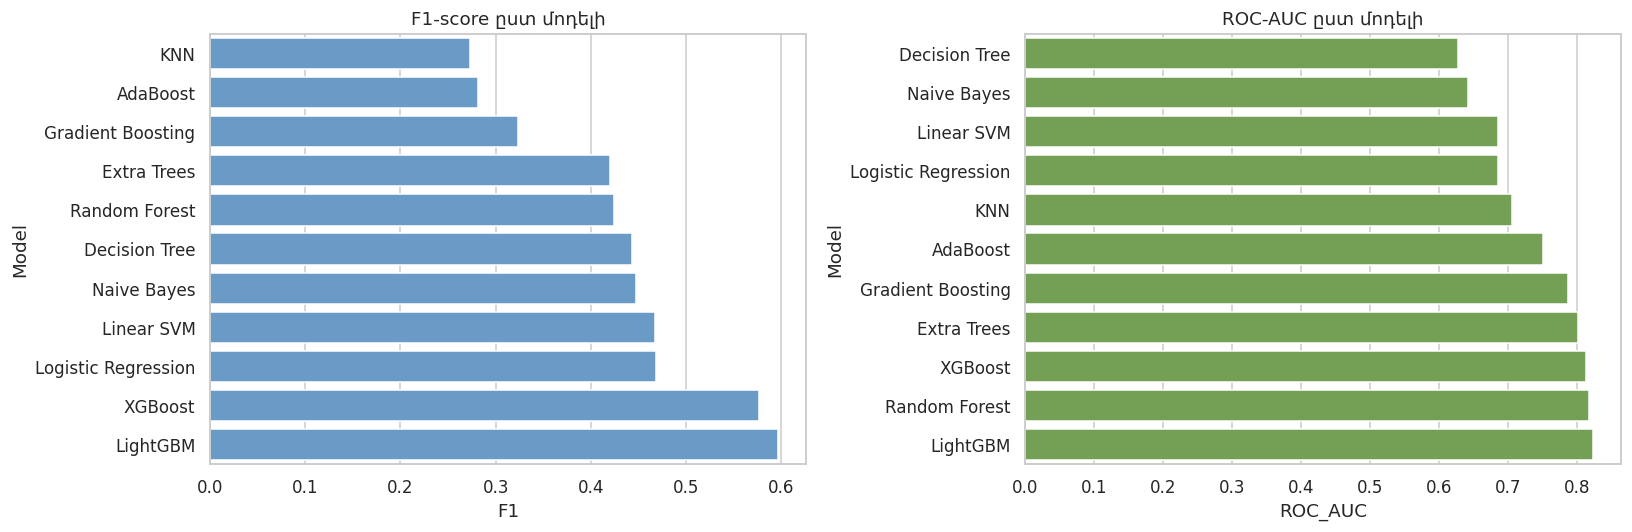

In [104]:
# Bar chart — մոդելների համեմատություն ըստ F1 և ROC-AUC

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = results_eng.sort_values("F1")["Model"]

sns.barplot(data=results_eng, y="Model", x="F1", order=order, ax=axes[0], color="#5b9bd5")
axes[0].set_title("F1-score ըստ մոդելի")
sns.barplot(data=results_eng.sort_values("ROC_AUC"), y="Model", x="ROC_AUC",
            ax=axes[1], color="#70ad47")
axes[1].set_title("ROC-AUC ըստ մոդելի")
plt.tight_layout()
plt.show()

Feature engineering-ի ազդեցությունը F1-ի վրա:
              Model  F1_baseline  F1_engineered  improvement
           LightGBM     0.591680       0.596349       0.0047
            XGBoost     0.579992       0.576605      -0.0034
Logistic Regression     0.468498       0.468707       0.0002
         Linear SVM     0.465664       0.467554       0.0019
        Naive Bayes     0.275182       0.447705       0.1725
      Decision Tree     0.446831       0.443145      -0.0037
      Random Forest     0.404112       0.423982       0.0199
        Extra Trees     0.345266       0.420131       0.0749
  Gradient Boosting     0.319366       0.323246       0.0039
           AdaBoost     0.232715       0.281293       0.0486
                KNN     0.247097       0.272571       0.0255


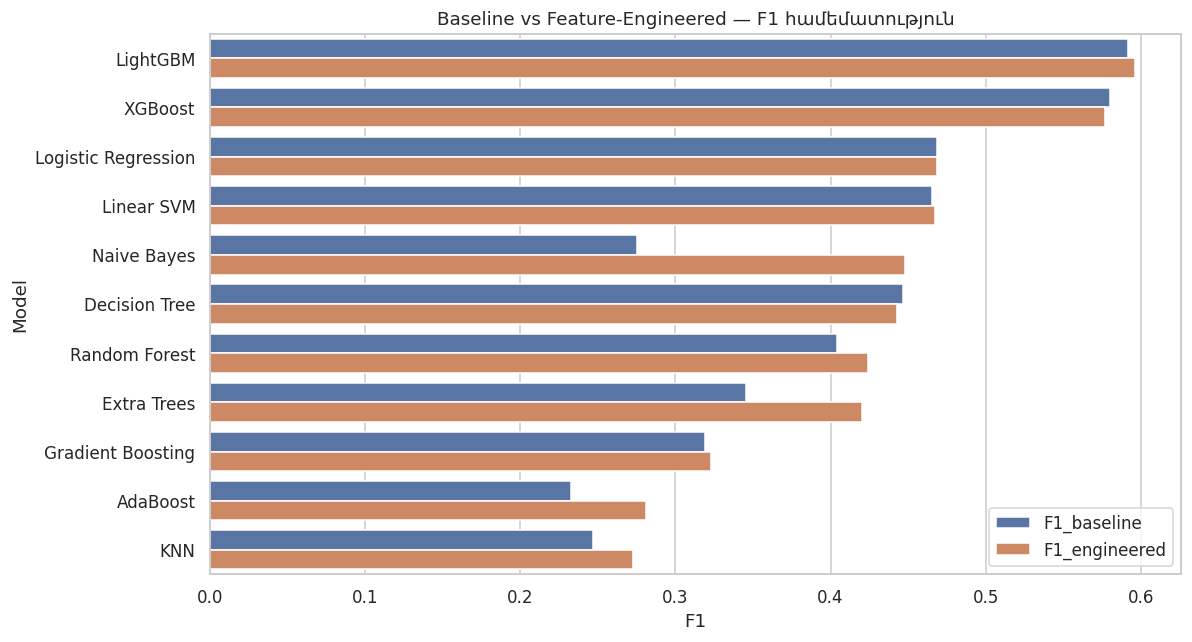

In [105]:
# Before vs After feature engineering — F1-ի փոփոխությունը
compare = results_base[["Model", "F1"]].merge(
    results_eng[["Model", "F1"]], on="Model", suffixes=("_baseline", "_engineered")
)
compare["improvement"] = (compare["F1_engineered"] - compare["F1_baseline"]).round(4)
compare = compare.sort_values("F1_engineered", ascending=False)
print("Feature engineering-ի ազդեցությունը F1-ի վրա:")
print(compare.to_string(index=False))

# գրաֆիկ
comp_melt = compare.melt(id_vars="Model", value_vars=["F1_baseline", "F1_engineered"],
                         var_name="version", value_name="F1")
plt.figure(figsize=(11, 6))
sns.barplot(data=comp_melt, y="Model", x="F1", hue="version")
plt.title("Baseline vs Feature-Engineered — F1 համեմատություն")
plt.legend(title="")
plt.tight_layout()
plt.show()

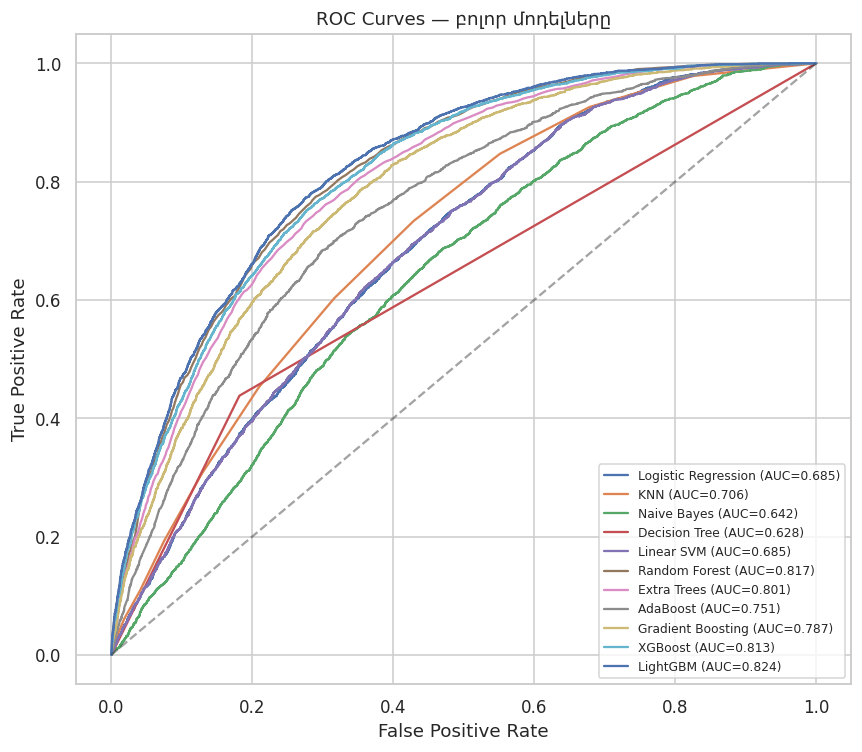

In [106]:
# ROC curves — բոլոր մոդելները մի գրաֆիկի վրա

plt.figure(figsize=(8, 7))
for name, score in proba_eng.items():
    fpr, tpr, _ = roc_curve(yte_e, score)
    auc = roc_auc_score(yte_e, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — բոլոր մոդելները")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

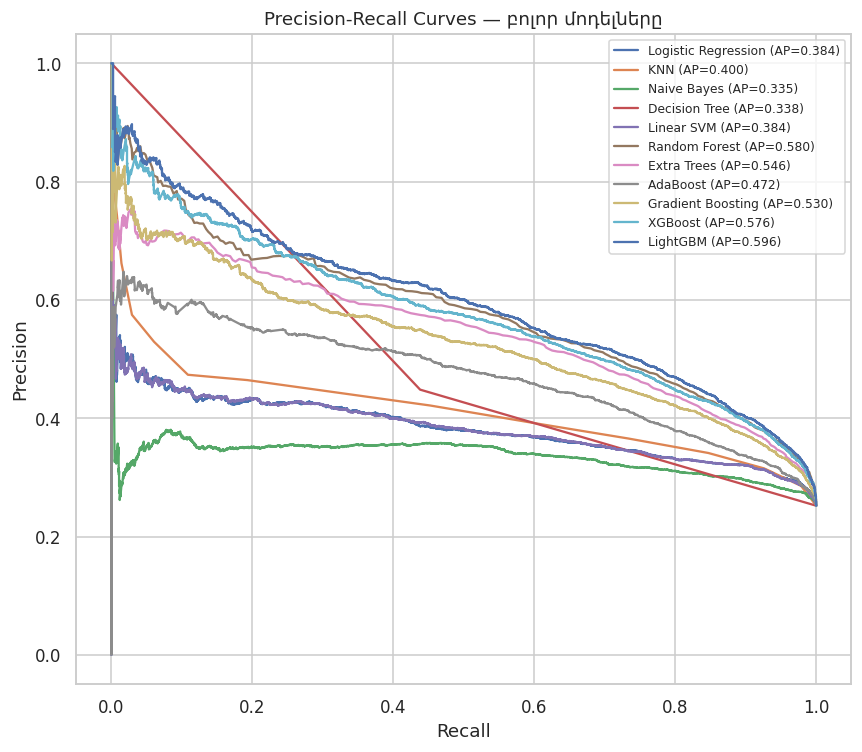

In [107]:
# Precision-Recall curves — սրանք imbalanced data-ի դեպքում ավելի informative են
plt.figure(figsize=(8, 7))
for name, score in proba_eng.items():
    prec, rec, _ = precision_recall_curve(yte_e, score)
    ap = average_precision_score(yte_e, score)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — բոլոր մոդելները")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


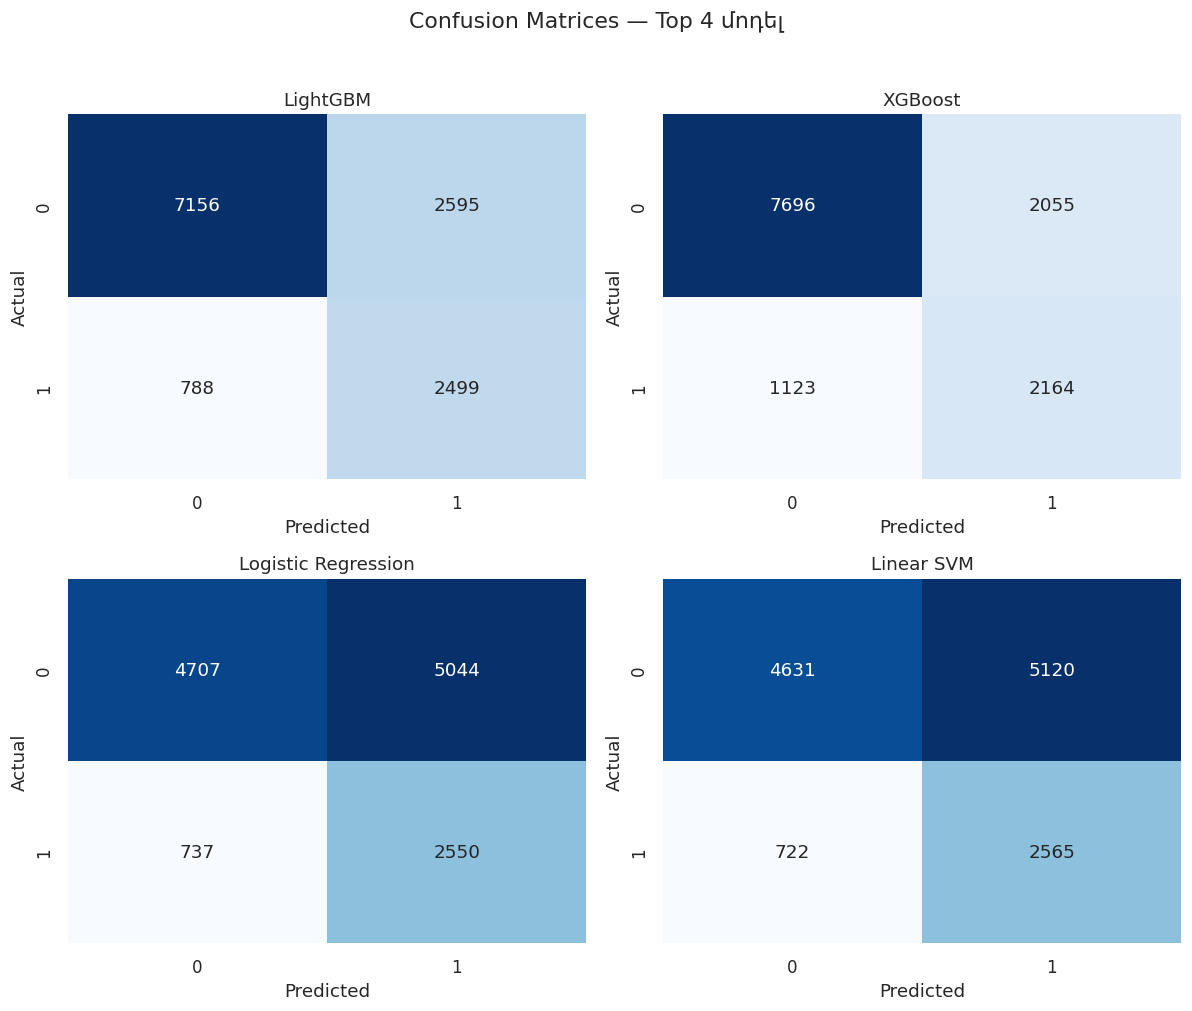

In [108]:
# Confusion matrix — լավագույն 4 մոդելի համար

top4 = results_eng.head(4)["Model"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.ravel(), top4):
    pred = fitted_eng[name].predict(Xte_e)
    cm = confusion_matrix(yte_e, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Top 4 մոդել", y=1.02)
plt.tight_layout()
plt.show()

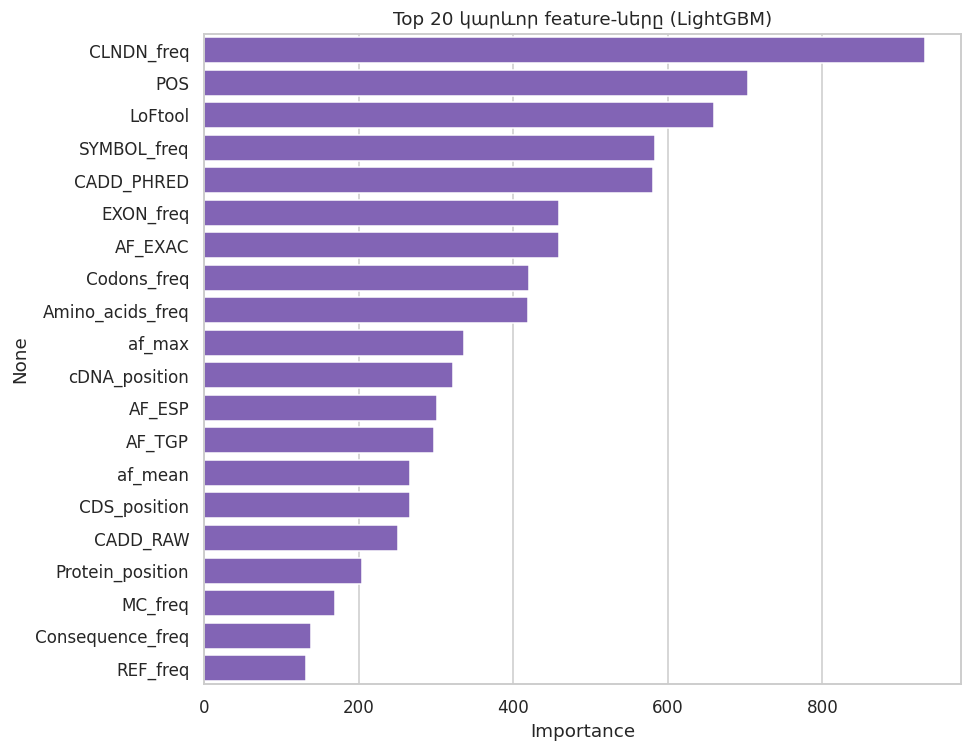


Նկատենք,որ մեր ստեղծած feature-ները (af_max, is_snv, n_missing) հայտնվել են կարևորների մեջ → դա ապացուցում է feature engineering-ի օգուտը։


In [109]:
# Feature importance — լավագույն tree-based մոդելից

tree_models = ["XGBoost", "LightGBM", "Random Forest", "Extra Trees", "Gradient Boosting"]
best_tree = next(m for m in results_eng["Model"] if m in tree_models)
model = fitted_eng[best_tree]

importances = pd.Series(model.feature_importances_, index=feat_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
sns.barplot(x=top20.values, y=top20.index, color="#7e57c2")
plt.title(f"Top 20 կարևոր feature-ները ({best_tree})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"\nՆկատենք,որ մեր ստեղծած feature-ները (af_max, is_snv, n_missing) "
      f"հայտնվել են կարևորների մեջ → դա ապացուցում է feature engineering-ի օգուտը։")

# **Եզրակացություն (Final Report)**
## ClinVar գենետիկ վարիանտների դասակարգում — Մեքենայական ուսուցման եզրափակիչ նախագիծ



Նախագիծը ցույց տվեց, որ մեքենայական ուսուցման մեթոդներով հնարավոր է ողջամիտ ճշգրտությամբ
կանխատեսել գենետիկ վարիանտների հակասական դասակարգման հավանականությունը։ Ensemble-ի վրա
հիմնված boosting մոդելները (XGBoost, LightGBM) գերազանցեցին գծային և հեռավորության վրա
հիմնված մոդելներին, ինչը բնական է բարդ, ոչ գծային և խառը-տիպի հատկանիշներով տվյալների
դեպքում։ Հատկանիշների ճարտարագիտությունը չափելի դրական ազդեցություն ունեցավ՝ հաստատելով
բնագավառի գիտելիքի կարևորությունը գենոմային տվյալների վերլուծության մեջ։

### Սահմանափակումներ

* **Class imbalance-ի պատճառով Accuracy-ն խաբուսիկ է** — այն չի կարող օգտագործվել որպես
  հիմնական չափանիշ։
* ClinVar-ի դասակարգումները ժամանակի ընթացքում թարմացվում են, ուստի մոդելը արտացոլում է
  տվյալների որոշակի պահի վիճակը (snapshot), ոչ թե բացարձակ ճշմարտություն։
* Մոդելը կանխատեսում է դասակարգման **հակասությունը**, ոչ թե անմիջապես վարիանտի
  ախտածինությունը. այն պետք է դիտարկել որպես **screening / աջակցության գործիք**, ոչ թե
  կլինիկական որոշման փոխարինիչ։



